In [2]:
''' Import required packages
'''

import sys
import time
import numpy as np
import matplotlib.pyplot as plt
import numba
import pandas as pd
import seaborn as sns
from matplotlib.animation import FuncAnimation
from scipy.stats import norm
from numba import njit, prange
from concurrent.futures import ProcessPoolExecutor
numba.config.FULL_TRACEBACKS = True

In [3]:
''' Sampling from the non-linear state-space model with
equations x_t+1 = atan(x_t) + theta_1 * u_t + v_t, v_t ~ N(0,1)
          y_t   = |x_t| + theta_1 * theta_2 + e_t, e_t ~ N(0,0.01).
True parameters used for sampling are not given explicitly in the
paper, so let us pick these ourselves: theta_1 = 1, theta_2 = 1.
'''

@njit
def g(x, theta):
    """ Deterministic part of the
    distribution ``p(y_t|x_t,theta)`` in the
    state-space model described above.
    
    Parameters
    -
    x              : float
                     Latent space variable
    theta          : ndarray of shape (2,)
                     Parameters for the state-space model
                     
    Returns
    -
    Deterministic part of observation
    """
    return np.abs(x) + theta[0] * theta[1]

@njit
def f(x, theta, u):
    """ Deterministic part of the
    distribution ``p(x_t|x_t-1,theta)`` in the
    state-space model described above.
    
    Parameters
    -
    x              : float
                     Previous latent-space state
    theta          : ndarray of shape (2,)
                     Parameters for the state-space model
    u              : float
                     Previous exogenous input parameter
    
    Returns
    -
    Deterministic part of next latent-space state
    """
    return np.atan(x) + theta[0] * u

    

def sample_state_space_model(us, T=200, theta=np.asarray([1,1]), rng=None):
    """Sample observations from the non-linear
    state-space model described in Svensson et al. (2017).

    Parameters
    -
    T     : int, default=500
            Number of time steps to simulate.
    theta : ndarray of shape (2,):
            Parameters of underlying state-space model.
    us    : ndarray of shape (T,):
            List of exogenous input variables.
    rng   : numpy rng object
            Random number generator to use for drawing samples,
            so that we can consistently look at the same
            observation sample for fair comparisons
            later down the line
          
    Returns
    -
    ys : ndarray of shape (T,)
        Simulated observations generated from the state space model.
    """
    
    # If no random generator is provided,
    # use the default.
    if rng is None:
        rng = np.random.default_rng()

    xs = np.zeros((T,)) # Storage for latent states
    ys = np.zeros((T,)) # Storage for observations
    xs[0] = 0 # Initial condition
    ys[0] = rng.normal(g(xs[0], theta),0.01)
    for i in range(1, T):
        # Evolve latent space according to formula
        # in Svensson et al. (2017).
        xs[i] = rng.normal(f(xs[i-1],theta,us[i-1]), 1)
        ys[i] = rng.normal(g(xs[i],theta),0.01)
    return ys

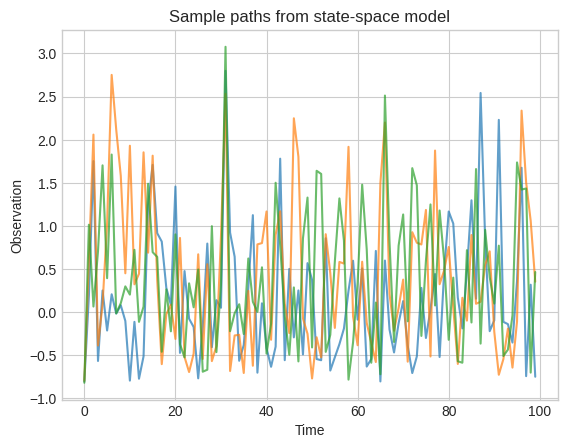

In [72]:
''' Draw sample paths from the state-space model defined above.
Do some quick visualization.
'''


n_paths = 3 # Number of paths to draw
T = 100 # Number of samples in each path

rng = np.random.default_rng(seed=42) # Want to fix this while keeping the rest random
us = rng.normal(loc=0, scale=1, size=T) # Fixed exogenous input variables

for _ in range(n_paths):
    ys = sample_state_space_model(us=us,T=T,theta=np.asarray([-1,0.8]),rng=rng)
    plt.plot(ys, alpha=0.7)

plt.title("Sample paths from state-space model")
plt.xlabel("Time")
plt.ylabel("Observation")
plt.show()

In [32]:
""" Implementation of the bootstrap particle filter
for this non-linear state-space model.
"""

@njit
def normal_logpdf(x, loc, scale):
    """ Compute log pdf of normal distribution
    with mean loc and variance scale.
    """
    return -0.5 * np.log(2*np.pi*scale) - 0.5 * (x - loc)**2 / scale

@njit
def logsumexp(x):
    """Fast numerically stable logsumexp
    """
    m = np.max(x)

    s = 0.0
    for i in range(len(x)):
        s += np.exp(x[i] - m)

    return m + np.log(s)


@njit
def multinomial_resample(weights):
    """Get resampled indices based on
    normalized weight vector.
    Fast njit-compatible version of
    multinomial resampling
    """
    N = len(weights)
    
    cdf = np.empty(N)

    cdf[0] = weights[0]

    for i in range(1, N):
        cdf[i] = cdf[i-1] + weights[i]

    out = np.empty(N, dtype=np.int64)

    for i in range(N):

        u = np.random.rand()
        out[i] = np.searchsorted(cdf, u)

    return out


@njit
def particle_filter(temp, n_particles, ys, us, theta, alternative_tempering=False):
    """ Bootstrap particle filter for the nonlinear
    state-space model defined above.
    
    Parameters
    -
    temp        : float
                  tempering parameter
    n_particles : int
                  number of particles to use
    ys          : ndarray of shape (T,)
                  List of observations from the 
                  underlying state-space model
    us          : ndarray of shape (T,)
                  List of exogenous input parameters
                  in the underlying state-space model
    theta       : ndarray of shape (2,)
                  Parameters of the underlying state-space
                  model
                  
    Returns
    -
    List of samples ``x_1:T`` of shape (n_particles,T) from the filtering
    distributions ``p(x_t|y_1:t,theta,temp)``, to be used
    in the approximation of the likelihood ``p(y_1:T|theta,temp)``
    
    List of internal resampling states ``a_2:T`` of shape (n_particlesT-1)

    Estimate of log-likelihood of the observations
    """
    
    # Ensure consistent shape for theta to make
    # numba work
    theta = np.asarray(theta).reshape(2,)
    
    T = len(ys) # Number of observations
    xs = np.zeros(shape=(n_particles,T)) # Particle storage
    aas = np.zeros(shape=(n_particles,T-1),dtype=np.int64) # Resampling storage
    
    # Baseline variance, only change if using the standard tempering scheme
    # (the one from Svensson et al.)
    var = 0.01
    if alternative_tempering == False:
        var += temp # Variance after tempering
    log_w = np.empty(n_particles) # Weight storage

    # Sample initial xs from ``p(x|theta)`` in the state-space model
    # Initial condition is just deterministically 0, so just set to 0
    xs[:,0] = np.zeros(n_particles)

    # Weight according to f(y_1|x_1,theta,temp) = N(|x_1| + theta1 * theta2, 0.01 + temp)
    # Recall: going from p(x|theta,temp) to p(x|y,theta,temp) = 
    # f(y|x,theta,temp)p(x|theta,temp) / p(y|theta,temp)
    # Recall: so up to x-proportionality, dQ(x)/dM(x) = f(y|x,theta,temp)    
    for i in range(n_particles):
        
        if alternative_tempering == False:
            log_w[i] = normal_logpdf(ys[0], loc=g(xs[i,0],theta), scale=var)
        else: # Alternatively, weigh according to f(y_1|x_1,theta,temp) = f(y_1|x_1,theta)^(1/temp)
            log_w[i] = normal_logpdf(ys[0], loc=g(xs[i,0],theta), scale=var) / temp
    
    # Iterate over timesteps
    lse = logsumexp(log_w) # Store logsumexp, use later
    log_lik = lse - np.log(n_particles) # Keep track of log-likelihood
    for t in range(1,T):

        # Normalize weights
        w_norm = np.exp(log_w - lse)
        
        # Resample indices according to the normalized weights
        aas[:,t-1] = multinomial_resample(w_norm)
        
        # Extend and reweight
        for i in range(n_particles):
            
            # Extend
            xs[i,t] = np.random.normal(
                                    loc=f(xs[aas[i,t-1],t-1],
                                    theta=theta,
                                    u=us[t-1]),
                                    scale=1)
            # Reweight
            if alternative_tempering == False:
                log_w[i] = normal_logpdf(ys[t], loc=g(xs[i,t],theta), scale=var)
            else: # Alternatively, weigh according to f(y_1|x_1,theta,temp) = f(y_1|x_1,theta)^(1/temp)
                log_w[i] = normal_logpdf(ys[t], loc=g(xs[i,t],theta), scale=var) / temp
        
        
        # Recall: likelihood is prod_t=1^T 1/N * sum_n=1^N g(y_t|x_t^n,temp)
        # So this can quickly be obtained from the PF by summing the
        # unnormalized weights
        lse = logsumexp(log_w) # Store logsumexp, reuse later
        log_lik += lse - np.log(n_particles) # Update log-likelihod

    return xs, aas, log_lik
    

In [123]:
""" Implementation of particle Metropolis-Hastings (PMH)
for this state-space model.
"""

@njit
def log_prior(theta):
    """Compute prior probability of observing
    parameter theta.
    
    Parameters
    -
    theta : ndarray of shape (2,)
            Parameter of state-space model
    """
    if 0 <= theta[0] <= 2 and 0 <= theta[1] <= 2:
        return 0.0
    else:
        return -np.inf

@njit
def sample_prior(n=1):
    """Sample from uniform prior
    on theta.
    
    Parameters
    -
    n : int
        Number of samples to draw
    """
    return np.random.uniform(0,2,size=(n,2))


@njit
def particle_metropolis_hastings(
    theta, 
    xs,
    aas,
    log_lik, 
    us,
    ys,
    temp,
    n_iters=1, 
    proposal_sd=0.01, 
    verbose=False,
    alternative_tempering=False
    ):
    """Draw samples from the posterior ``p(theta|y_1:T,temp)`` 
    of the tempered non-linear state space model described above,
    using a random-walk particle Metropolis-Hastings algorithm with 
    bivariate normal proposal.
    
    Parameters
    -
    theta         : ndarray of shape (2,)
                    Initial parameter value
    xs            : ndarray of shape (n_particles,T)
                    Particles used for sampling the initial
                    parameter value
    aas           : ndarray of shape (n_particles,T-1)
                    Internal resampling state of the particle
                    filter used for sampling the initial parameter
                    value
    log_lik       : np.float64
                    Log-likelihood obtained from the particle filter
                    used when sampling the initial parameter value
    temp          : float
                    Tempering parameter of the distribution to sample
                    from.
    ys            : ndarray of shape (T,)
                    List of observations on which the distribution to
                    sample from is conditioned.
    n_iters       : int, default=1
                    Number of iterations to run the Metropolis-Hastings
                    algorithm for.
    proposal_sd   : float, default=0.01
                    Standard deviation of the proposal distribution.
    verbose       : Boolean, default=False
                    Whether or not to print additional diagnostic information
                    while running the algorithm
                    
    Returns
    -
    thetas : ndarray of shape (n_iters,2)
             List of M-H parameter samples
    xss    : ndarray of shape (n_iters, n_particles,T)
             List of internal particles for estimation of M-H samples
    aass   : ndarray of shape (n_iters,n_particles,T-1)
             List of internal particle filter resampling states for
             estimation of M-H samples
    """
    T = len(ys) # Number of observations
    n_particles = xs.shape[0] # Number of particles
    n_accepts = 0 # Keep track of acceptance rate
    var = 0.01 + temp # Observation variance after tempering
    
    # Keep track of all samples, including the initial sample
    thetas = np.zeros(shape=(n_iters+1,2))
    thetas[0] = theta.flatten()

    log_liks = np.zeros(shape=(n_iters,)) # Keep track of sample log likelihoods
    
    # Keep track of all internal states, including the initial state
    xss = np.zeros(shape=(n_iters+1,n_particles,T))
    aass = np.zeros(shape=(n_iters+1,n_particles,T-1),dtype=np.int64)
    xss[0,:,:] = xs
    aass[0,:,:] = aas
     
    for i in range(1,n_iters+1):
        
        # Propose new parameter according to a
        # random walk proposal
        # We have to do it explicitly (without, for example,
        # np.multivariate_normal) to make it work
        # with numba. Worth it!
        eps0 = np.random.normal()
        eps1 = np.random.normal()
        new_theta = np.array([
            thetas[i-1, 0] + proposal_sd * eps0,
            thetas[i-1, 1] + proposal_sd * eps1
        ])
        
        # Run particle filter using this new parameter value
        new_xss, new_aass, new_log_lik = particle_filter(
                                    temp=temp,
                                    n_particles=n_particles,
                                    ys=ys,
                                    us=us,
                                    theta=new_theta,
                                    alternative_tempering=alternative_tempering)
        
        # Sample value uniform on [0,1]
        d = np.random.uniform(0,1)
        
        # Compute log of the acceptance probability
        log_alpha = new_log_lik + log_prior(new_theta) - \
                    log_lik - log_prior(thetas[i-1])
        
        # If d < min(alpha,1), keep thetas[i], xss[:,:,i], aas[:,:,i] the same.
        # Otherwise, change them back to their previous values.
        if np.log(d) < min(log_alpha, 0):
            log_lik = new_log_lik
            xss[i,:,:] = new_xss
            aass[i,:,:] = new_aass
            thetas[i] = new_theta
            log_liks[i] = log_lik
            n_accepts += 1
        else:
            thetas[i] = thetas[i-1]
            log_liks[i] = log_lik
            xss[i,:,:] = xss[i-1,:,:]
            aass[i,:,:] = aass[i-1,:,:]
    
    accept_rate = n_accepts / n_iters
    return thetas[1:], xss[1:,:,:], aass[1:,:,:], log_liks, accept_rate


@njit
def adaptive_particle_metropolis_hastings(
    theta, 
    xs,
    aas,
    log_lik, 
    us,
    ys,
    temp,
    proposal_chol,
    n_iters=1, 
    verbose=False,
    alternative_tempering=False
    ):
    """Draw samples from the posterior ``p(theta|y_1:T,temp)`` 
    of the tempered non-linear state space model described above,
    using a random-walk particle Metropolis-Hastings algorithm with 
    bivariate normal proposal.
    This is an adaptive version of the PMMH algorithm, taking as random
    walk parameter the Cholesky decomposition of its desired covariance
    matrix, rather than a numerical standard deviation.
    
    Parameters
    -
    theta         : ndarray of shape (2,)
                    Initial parameter value
    xs            : ndarray of shape (n_particles,T)
                    Particles used for sampling the initial
                    parameter value
    aas           : ndarray of shape (n_particles,T-1)
                    Internal resampling state of the particle
                    filter used for sampling the initial parameter
                    value
    log_lik       : np.float64
                    Log-likelihood obtained from the particle filter
                    used when sampling the initial parameter value
    temp          : float
                    Tempering parameter of the distribution to sample
                    from.
    ys            : ndarray of shape (T,)
                    List of observations on which the distribution to
                    sample from is conditioned.
    n_iters       : int, default=1
                    Number of iterations to run the Metropolis-Hastings
                    algorithm for.
    proposal_chol : ndarray of shape (2,2)
                    Cholesky decomposition of the covariance matrix of the propoosal distribution
    verbose       : Boolean, default=False
                    Whether or not to print additional diagnostic information
                    while running the algorithm
                    
    Returns
    -
    thetas : ndarray of shape (n_iters,2)
             List of M-H parameter samples
    xss    : ndarray of shape (n_iters, n_particles,T)
             List of internal particles for estimation of M-H samples
    aass   : ndarray of shape (n_iters,n_particles,T-1)
             List of internal particle filter resampling states for
             estimation of M-H samples
    """
    T = len(ys) # Number of observations
    n_particles = xs.shape[0] # Number of particles
    n_accepts = 0 # Keep track of acceptance rate
    var = 0.01 + temp # Observation variance after tempering
    
    # Keep track of all samples, including the initial sample
    thetas = np.zeros(shape=(n_iters+1,2))
    thetas[0] = theta.flatten()

    log_liks = np.zeros(shape=(n_iters,)) # Keep track of sample log likelihoods
    
    # Keep track of all internal states, including the initial state
    xss = np.zeros(shape=(n_iters+1,n_particles,T))
    aass = np.zeros(shape=(n_iters+1,n_particles,T-1),dtype=np.int64)
    xss[0,:,:] = xs
    aass[0,:,:] = aas
     
    for i in range(1,n_iters+1):
        
        # Propose new parameter according to a
        # random walk proposal
        # We have to do it explicitly (without, for example,
        # np.multivariate_normal) to make it work
        # with numba. Worth it!
        eps0 = np.random.normal()
        eps1 = np.random.normal()
        delta_theta_0 = proposal_chol[0, 0] * eps0 + proposal_chol[0, 1] * eps1
        delta_theta_1 = proposal_chol[1, 0] * eps0 + proposal_chol[1, 1] * eps1
        
        new_theta = np.array([
            thetas[i-1, 0] + delta_theta_0,
            thetas[i-1, 1] + delta_theta_1
        ])
        
        # Run particle filter using this new parameter value
        new_xss, new_aass, new_log_lik = particle_filter(
                                    temp=temp,
                                    n_particles=n_particles,
                                    ys=ys,
                                    us=us,
                                    theta=new_theta,
                                    alternative_tempering=alternative_tempering)
        
        # Sample value uniform on [0,1]
        d = np.random.uniform(0,1)
        
        # Compute log of the acceptance probability
        log_alpha = new_log_lik + log_prior(new_theta) - \
                    log_lik - log_prior(thetas[i-1])
        
        # If d < min(alpha,1), keep thetas[i], xss[:,:,i], aas[:,:,i] the same.
        # Otherwise, change them back to their previous values.
        if np.log(d) < min(log_alpha, 0):
            log_lik = new_log_lik
            xss[i,:,:] = new_xss
            aass[i,:,:] = new_aass
            thetas[i] = new_theta
            log_liks[i] = log_lik
            n_accepts += 1
        else:
            thetas[i] = thetas[i-1]
            log_liks[i] = log_lik
            xss[i,:,:] = xss[i-1,:,:]
            aass[i,:,:] = aass[i-1,:,:]
    
    accept_rate = n_accepts / n_iters
    return thetas[1:], xss[1:,:,:], aass[1:,:,:], log_liks, accept_rate

Particle filter took 0.003632783889770508s
PMH took 1.0181019306182861s
Acceptance rate of initial PMH sample: 0.8766666666666667


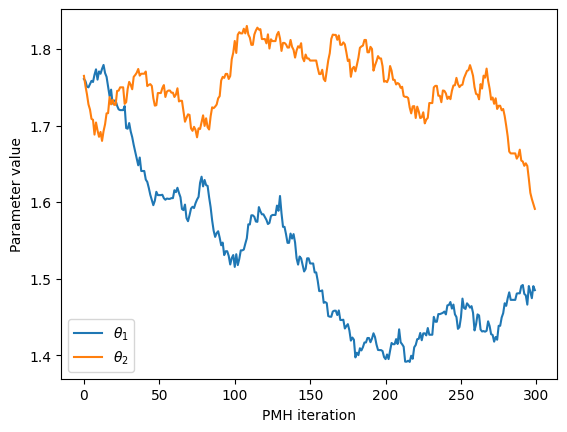

In [ ]:
""" Test whether the PMH sampling works by sampling
an intiial estimate from the posterior p(theta|y_1:T,temp)
"""

temp = 10 # Initial tempering
T = 100 # Number of observations
                              
# Exogenous input variables
rng = np.random.default_rng(seed=42) # Want to fix this while keeping the rest random
us = rng.normal(loc=0, scale=1, size=T)

# Sample observations from true state-space model
ys = sample_state_space_model(T=T,us=us,rng=rng)

# Sample theta from parameter prior
theta = sample_prior()

# Generate particle approximations for p(y_t|x_1:T,theta,temp)
# for the initial parameter sample
t0 = time.time()
xs, aas, log_lik = particle_filter(temp=temp,
                          n_particles=300,
                          ys=ys,
                          us=us,
                          theta=theta,
                          alternative_tempering=False
                          )
t1 = time.time()
print(f'Particle filter took {t1 - t0}s')

# Run PMH
t0 = time.time()

samples, xss, aass, log_liks, accept_rate = particle_metropolis_hastings(
    xs=xs,
    aas=aas,
    log_lik=log_lik,
    theta=theta,
    ys=ys,
    us=us,
    temp=temp,
    n_iters=300,
    proposal_sd=0.01,
    verbose=True,
    alternative_tempering=False
)
t1 = time.time()
print(f'PMH took {t1 - t0}s')
print(f'Acceptance rate of initial PMH sample: {accept_rate}')

# Plot result
plt.plot(samples[:,0],label=r'$\theta_1$')
plt.plot(samples[:,1],label=r'$\theta_2$')
plt.xlabel('PMH iteration')
plt.ylabel('Parameter value')
plt.legend()

In [151]:
""" Implementation of the complete algorithm described in
Svensson et al., applied to their example nonlinear state-space
model.
"""

@njit
def ess(cur_log_pos, nxt_log_pos):
    """Compute the effective sample size for the set
    of weights the log of which is given by nxt_log_pos - cur_log_pos.
    
    Parameters
    -
    cur_log_opos  : ndarray of size (N,)
                    List of logs of evaluations of the 'proposal distribution'
                    (up to proportionality) in a set of sample points.
    nxt_log_pos   : ndarray of size (N,)
                    List of logs of evaluations of the 'true distribution'
                    (up to proportionality) in a set of sample points.
    
    Comments
    -
    Works in log-scale to avoid numerical difficulties.
    """
    
    cur = np.asarray(cur_log_pos)
    nxt = np.asarray(nxt_log_pos)

    log_w = nxt - cur

    m = np.max(log_w)
    w = np.exp(log_w - m)
    w = w / np.sum(w)

    return 1.0 / np.sum(w**2)


@njit
def get_log_pos(temp, thetas, ys, xss, aass, alternative_tempering=False):
    """ Compute the log of the
    posterior p(theta,(xs,aas)|temp,ys)
    up to proportionality.
    
    Parameters
    -
    temp   : float
             tempering parameter
    thetas : ndarray of size (n_sample_particles,2)
             list of parameter samples
    ys     : ndarray of size (T,)
             list of observations from the
             true state-space model
    xss    : ndarray of size (n_filter_particles,T,n_sample_particles)
             list of particles obtained for estimation
             of likelihoods p(ys|theta,(xs,aas),temp)
    aass   : ndarray of size (n_filter_particles,T-1,n_sample_particles)
             list of resampling indices obtained for
             estimation of likelihoods
             p(ys|theta,(xs,aas),temp)
    
    Returns
    -
    log_pos : ndarray of size (n_sample_particles,)
            list of logs of posteriors p(theta,(xs,aas)|temp,ys) up to
            proportionality, for theta in thetas
    """
    # recall xss.shape = (n_sample_particles,n_filter_particles,T)
    n_sample_particles, n_filter_particles, T = xss.shape
    
    var = 0.01
    if alternative_tempering == False: # Only change variance when using standard tempering scheme
        var = 0.01 + temp 
    
    log_pos = np.zeros(n_sample_particles, dtype=np.float64)
    
    # Avoids unnecessary allocations
    inner = np.empty(n_filter_particles, dtype=np.float64)
    
    for m in range(n_sample_particles):
        theta_m = thetas[m]
        log_pos_m = 0.0
        
        for t in range(T):
            y_t = ys[t]
            
            # Calculate inner log-pdfs
            for n in range(n_filter_particles):
                if alternative_tempering == False:
                    inner[n] = normal_logpdf(y_t, loc=g(xss[m, n, t], theta_m), scale=var)
                else: # Because f(y_1|x_1,theta,temp) = f(y_1|x_1,theta)^(1/temp) under alternative tempering scheme
                    inner[n] = normal_logpdf(y_t, loc=g(xss[m, n, t], theta_m), scale=var) / temp
            
            lse = logsumexp(inner) 
            log_pos_m += lse

            # Second term for 0 to T-2
            if t < T - 1:
                for n in range(n_filter_particles):
                    idx = aass[m, n, t]
                    if alternative_tempering == False:
                        log_pos_m += normal_logpdf(y_t, loc=g(xss[m, idx, t], theta_m), scale=var) - lse
                    else:
                        log_pos_m += (normal_logpdf(y_t, loc=g(xss[m, idx, t], theta_m), scale=var) / temp) - lse
                    
        log_pos[m] = log_pos_m
        
    return log_pos


@njit
def bisect(prev_log_pos, 
           thetas, 
           ys, 
           xss, 
           aass, 
           c, 
           lo, 
           hi, 
           max_iter=50, 
           tol=1e-2, 
           verbose=False,
           alternative_tempering=False):
    """ Approximately compute the point of
    intersection between func_to_bisect 
    and the line y = c using the bisection method.
    
    Parameters
    -
    prev_log_pos : ndarray of shape (n_sample_particles,)
                 List of log of posteriors (up to proportionality)
                 for the previous tempering value
    thetas     : ndarray of shape (n_sample_particles,)
                 List of sample particles
    ys         : ndarray of shape (T,)
                 List of observations from the true
                 state-space model
    xss        : ndarray of shape (n_particles,T,n_sample_particles)
                 All particles used in likelihood approximation
                 corresponding to parameter values in thetas
    aass       : ndarray of shape (n_particles,T-1,n_sample_particles)
                 All resampling indices used in likelihood approxmimation
                 corresponding to parameter values in thetas
    c          : float
                 y-coordinate of the intersection line.
    lo         : float
                 x-coordinate of the lower extent of the 
                 initial bisection interval.
    hi         : float
                 x-coordinate of the upper extent of the
                 initial bisection interval.
    max_iter   : int
                 Number of iterations to try bisection for.
    tol        : float
                 How close to c a result can be to count
                 as an intersection. 
    verbose    : Boolean, default=False
                 Whether or not to display additional
                 diagnostic information.

    Returns
    -
    Tempering parameter for which the equation
    approximately holds.
    """
    
    # Evaluate lower bound
    nxt_log_pos_lo = get_log_pos(lo, thetas, ys, xss, aass, alternative_tempering)
    flo = ess(prev_log_pos, nxt_log_pos_lo) - c
    
    # Impossible in this case, return
    if flo > 0:
        return lo, nxt_log_pos_lo
        
    # Evaluate upper bound
    nxt_log_pos_hi = get_log_pos(hi, thetas, ys, xss, aass, alternative_tempering)
    fhi = ess(prev_log_pos, nxt_log_pos_hi) - c
    
    # Impossible in this case, return
    if flo * fhi > 0:
        return (lo + hi) / 2, nxt_log_pos_hi

    mid = (lo + hi) / 2
    nxt_log_pos_mid = get_log_pos(mid, thetas, ys, xss, aass, alternative_tempering)

    
    for i in range(max_iter):
        mid = (lo + hi) / 2
        nxt_log_pos_mid = get_log_pos(mid, thetas, ys, xss, aass, alternative_tempering)
        fmid = ess(prev_log_pos, nxt_log_pos_mid) - c
                
        # Found midpoint
        if np.abs(fmid) < tol:
            return mid, nxt_log_pos_mid
        
        # Sign check
        if flo * fmid < 0:
            hi = mid
            fhi = fmid
        else:
            lo = mid
            flo = fmid

    return (lo + hi) / 2, nxt_log_pos_mid


@njit(parallel=True)
def run_parallel_mutation(thetas, 
                          xss, 
                          aass, 
                          log_liks, 
                          temp, 
                          ys, 
                          us, 
                          mh_iters, 
                          mh_sd,
                          alternative_tempering=False,
                          adaptive_pmh=False):
    """ Mutate particles using PMMH in parallel
    """
    n_samples = thetas.shape[0]
    accept_rates = np.empty(n_samples, dtype=np.float64)

    if adaptive_pmh and temp < 1: # Only start adapting later on. The threshold is arbitrary
        # Do the adaptive Cholesky decomposition thing
        cov = np.cov(thetas, rowvar=False)
        scaled_cov = (2.38**2 / 2.0) * cov + np.eye(2) * 1e-6
        proposal_chol = np.linalg.cholesky(scaled_cov)
        
        for m in prange(n_samples):
            # We pass slices. Note: slicing the last dimension [:,:,m] is 
            # slow in NumPy but Numba handles it reasonably well.
            # Ensure particle_metropolis_hastings is @njit
            theta_chain, xss_chain, aass_chain, log_lik_chain, acc = adaptive_particle_metropolis_hastings(
                theta=thetas[m],
                xs=xss[m,:,:],
                aas=aass[m,:,:],
                temp=temp,
                log_lik=log_liks[m],
                ys=ys,
                us=us,
                n_iters=mh_iters,
                proposal_chol=proposal_chol,
                verbose=False,
                alternative_tempering=alternative_tempering,
            )
            
            # Update the main arrays with the last link in the MH chain
            thetas[m] = theta_chain[-1]
            log_liks[m] = log_lik_chain[-1]
            xss[m,:,:] = xss_chain[-1,:,:]
            aass[m,:,:] = aass_chain[-1,:,:]
            accept_rates[m] = acc
            
    else: # PMMH without adaptation
    
        # Numba will distribute these iterations across all CPU cores
        for m in prange(n_samples):
            # We pass slices. Note: slicing the last dimension [:,:,m] is 
            # slow in NumPy but Numba handles it reasonably well.
            # Ensure particle_metropolis_hastings is @njit
            theta_chain, xss_chain, aass_chain, log_lik_chain, acc = particle_metropolis_hastings(
                theta=thetas[m],
                xs=xss[m,:,:],
                aas=aass[m,:,:],
                temp=temp,
                log_lik=log_liks[m],
                ys=ys,
                us=us,
                n_iters=mh_iters,
                proposal_sd=mh_sd,
                verbose=False,
                alternative_tempering=alternative_tempering,
            )

            # Update the main arrays with the last link in the MH chain
            thetas[m] = theta_chain[-1]
            log_liks[m] = log_lik_chain[-1]
            xss[m,:,:] = xss_chain[-1,:,:]
            aass[m,:,:] = aass_chain[-1,:,:]
            accept_rates[m] = acc

    return accept_rates.mean()


def smc_sampler(ys, 
                us, 
                initial_mh_iters, 
                initial_mh_sd, 
                mh_iters, 
                mh_sd, 
                n_sample_particles,
                n_filter_particles, 
                temp, 
                min_temp, 
                alpha,
                max_smc_iters=30, 
                verbose=False,
                alternative_tempering=False,
                adaptive_pmh=False
                ):
    """Tempered SMC sampler for approximate sampling from the
    parameter posterior of the linear-Gaussian state space model
    described in Svensson et al. (2017).
    
    Parameters
    -
    ys                    : ndarray of size (T,)
                            List of observations to condition on in the posterior.
    us                    : ndarray of size (T,)
                            List of exogenous input variables in the state-space model.
    initial_mh_iters      : int
                            Number of iterations to run the Metropolis-Hastings
                            kernel for the initial sample.
    initial_mh_sd         : float
                            Standard deviation of the proposal distribution in the
                            Metropolis-Hastings kernel for the initial sample.
    mh_iters              : int
                            Number of iterations to run the mutation Metropolis-Hastings
                            kernel for.
    mh_sd                 : float
                            Standard deviation of the proposal distribution in the mutation
                            Metropolis-Hastings kernel.
    n_sample_particles    : int
                            Number of particles to simulate / number of samples to draw.
    n_filter_particles    : int
                            Number of particles to use for particle filtering
    temp: float
                            Initial tempering parameter.
    min_temp              : float
                            Minimum tempering parameter; when reaching at most this temperature,
                            terminate.
    alpha                 : float
                            Adaptive tempering such that ESS remains approximately alpha * n_sample_particles
    max_smc_iters         : int
                            How many tempering iterations of the SMC sampler are allowed before
                            we forcibly terminate.
    verbose               : Boolean, default=False
                            Whether or not to display additional diagnostic information
    alternative_tempering : Boolean, default=False
                            Whether to apply tempering in another way (see report)
    adaptive_pmh          : Boolean, default=False
                            Whether to keep mutation PMMH sd fixed, or to adapt it
                            to the the covariance of the particles                       
                            
    Returns
    -
    samples : ndarray of size (n_particles,2)
              Approximate samples from the posterior p(theta|y_1:T,temp)
    iteration_records : dictionary containing some diagnostic data
    """
    
    T = len(ys) # Number of observations
    p = 0 # Iteration counter
    iteration_records = {} # Keep diagnostic information
    ess_target = alpha * n_sample_particles # Aim to keep this ESS

    ######## Initial sample ########
    
    theta = sample_prior() # Starting parameter from prior
    
    # Particle filter, because particle approximations of
    # p(y_t|x_1:T,theta,temp) are needed for PMH
    xs, aas, log_lik = particle_filter(
                            n_particles=n_filter_particles,
                            temp=temp,
                            ys=ys,
                            us=us,
                            theta=theta,
                            alternative_tempering=alternative_tempering)
    
    # Draw the initial sample using PMH,
    # using a burn-in period of size initial_mh_iters - n_particles
    thetas, xss, aass, log_liks, mean_accept_rate = particle_metropolis_hastings(
                                        theta=theta,
                                        xs=xs,
                                        aas=aas,
                                        temp=temp,
                                        log_lik=log_lik,
                                        us=us,
                                        ys=ys,
                                        n_iters=initial_mh_iters,
                                        proposal_sd=initial_mh_sd,
                                        verbose=False,
                                        alternative_tempering=alternative_tempering)
    thetas = thetas[-n_sample_particles:]
    log_liks = log_liks[-n_sample_particles:]
    xss = xss[-n_sample_particles:,:,:]
    aass = aass[-n_sample_particles:,:,:]
        
    ######## While tempering not sufficiently small... ########
    
    while temp > min_temp:
        
        # Update diagnostics
        iteration_records[p] = {'temp': temp, 
                                'particles': thetas,
                                'log_likelihoods': log_liks,
                                'accept_rate': mean_accept_rate}
        
        p = p + 1 # Counter update

        if verbose:
            print(f'New iteration: p = {p}')
        
        ######## Adaptive tempering ########

        # Compute proportional log posterior for all samples
        # under the current tempering
        log_pos = get_log_pos(temp=temp,
                        thetas=thetas,
                        ys=ys,
                        xss=xss,
                        aass=aass)

        if verbose:
            print(f'Starting bisection...')
            t0 = time.time()

        # Intersect with ess_target to
        # find next tempering parameter
        temp, nxt_log_pos = bisect(prev_log_pos=log_pos,
                          thetas=thetas,
                          ys=ys,
                          xss=xss,
                          aass=aass,
                          c=ess_target,
                          lo=min_temp,
                          hi=temp,
                          verbose=False,
                          alternative_tempering=alternative_tempering)

        if verbose:
            t1 = time.time()
            print(f'Updated temperature, new temperature is: {temp}')
            print(f'Bisection took {t1-t0}s')

        ######## Normalize weights and resample ########

        log_w = nxt_log_pos - log_pos # weights propto next posterior / prev posterior
        w_norm = np.exp(log_w - logsumexp(log_w)) # Normalize

        idxs = multinomial_resample(w_norm) # Resampling indices

        # Resample
        thetas = thetas[idxs]
        log_liks = log_liks[idxs]
        xss = xss[idxs,:,:]
        aass = aass[idxs,:,:]
        
        ######## Mutate using PMH ########

        if verbose:
            print(f'Starting mutation...')
            t0 = time.time()

        # This one line replaces the entire mutation loop/pool logic
        mean_accept_rate = run_parallel_mutation(
                                            thetas=thetas, 
                                            xss=xss, 
                                            aass=aass, 
                                            log_liks=log_liks, 
                                            temp=temp, 
                                            ys=ys, 
                                            us=us, 
                                            mh_iters=mh_iters, 
                                            mh_sd=mh_sd,
                                            alternative_tempering=alternative_tempering,
                                            adaptive_pmh=adaptive_pmh
                                            )

        if verbose:
            t1 = time.time()
            print(f'Finished mutation. Mutation took {t1-t0}s')
            print(f'Mean accept rate: {mean_accept_rate}')

        # If accept rates of mutation steps are too bad,
        # terminate (heuristic from paper).
        if mean_accept_rate < 0.05:
            break 


    # Final diagnostic update
    iteration_records[p] = {'temp': temp, 
                            'particles': thetas,
                            'log_likelihoods': log_liks,
                            'accept_rate': mean_accept_rate}
    return thetas, iteration_records

In [152]:
temp = 10.0 # Initial tempering
T = 200 # Number of observations
                              
# Exogenous input variables
rng = np.random.default_rng(seed=42) # Want to fix this while keeping the rest random
us = rng.normal(loc=0, scale=1, size=T)

# Sample observations from true state-space model
ys = sample_state_space_model(T=T,us=us,rng=rng)

samples, records = smc_sampler(
    ys=ys,
    us=us,
    initial_mh_iters=300,
    initial_mh_sd=0.5,
    mh_iters=10,
    mh_sd=0.1,
    n_sample_particles=100,
    n_filter_particles=300,
    temp=temp,
    min_temp=0.01,
    alpha=0.4,
    verbose=True,
    alternative_tempering=False,
    adaptive_pmh=True
)

New iteration: p = 1
Starting bisection...
Updated temperature, new temperature is: 9.55199264526367
Bisection took 1.9545612335205078s
Starting mutation...
Finished mutation. Mutation took 11.892420053482056s
Mean accept rate: 0.747
New iteration: p = 2
Starting bisection...
Updated temperature, new temperature is: 9.149046712558484
Bisection took 1.1496787071228027s
Starting mutation...
Finished mutation. Mutation took 0.7599201202392578s
Mean accept rate: 0.737
New iteration: p = 3
Starting bisection...
Updated temperature, new temperature is: 8.71786488218692
Bisection took 1.0686461925506592s
Starting mutation...
Finished mutation. Mutation took 0.7596406936645508s
Mean accept rate: 0.7580000000000001
New iteration: p = 4
Starting bisection...
Updated temperature, new temperature is: 8.351671101435773
Bisection took 1.0302278995513916s
Starting mutation...
Finished mutation. Mutation took 0.7670392990112305s
Mean accept rate: 0.7439999999999999
New iteration: p = 5
Starting bisect

KeyboardInterrupt: 

[1.05303894 0.96581547]


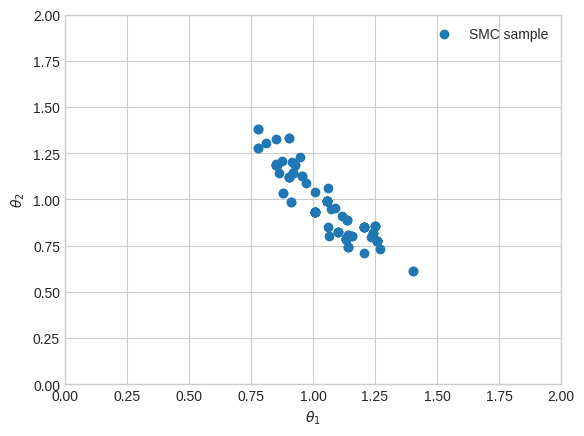

In [148]:
# Plot result
plt.scatter(samples[:,0],samples[:,1],label=r'SMC sample')
plt.xlim(0,2)
plt.ylim(0,2)
plt.xlabel(r'$\theta_1$')
plt.ylabel(r'$\theta_2$')
plt.legend()

print(np.mean(samples,axis=0))

# print(np.mean([x['particles'] for x in records.values()], axis=1))

In [149]:

""" Given SMC sampler particle history, draw a gif animation of the particle
evolution. Used AI for this one.
"""

# FIX: Safely check for the style string directly inside the list object
if 'seaborn-v0_8-whitegrid' in plt.style.available:
    plt.style.use('seaborn-v0_8-whitegrid')
else:
    plt.style.use('default')

fig, ax = plt.subplots(figsize=(8, 6), dpi=120)

# --- 1. Prepare your data ---
# Renamed to `record` per your instruction!
# Expected structure: { p: {'temp': float, 'particles': ndarray(N, 2)} }
iterations = sorted(list(records.keys()))

# Set absolute boundaries based on global mins and maxes of all particles
all_particles = np.vstack([records[p]['particles'] for p in iterations])
x_min, x_max = all_particles[:, 0].min() - 0.2, all_particles[:, 0].max() + 0.2
y_min, y_max = all_particles[:, 1].min() - 0.2, all_particles[:, 1].max() + 0.2


# --- 2. Initialize the plot elements ---
scatter = ax.scatter([], [], c='#1f77b4', alpha=0.5, s=15, edgecolors='none', label='Particles', zorder=3)

# FIX: Removed the trailing comma here because ax.add_line returns a single object
mean_dot = ax.add_line(plt.Line2D([], [], color='#d62728', marker='o', markersize=8, ls='', label='Empirical Mean', zorder=4))

title_text = ax.set_title('', fontsize=12, fontweight='bold', pad=10)

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_xlabel(r'$\theta_1$', fontsize=11)
ax.set_ylabel(r'$\theta_2$', fontsize=11)
ax.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')

# Global list container to clear previous contour paths on every frame cycle
kde_container = []

# --- 3. Define the frame update function ---
def update(frame_idx):
    p = iterations[frame_idx]
    data = records[p] # Using the updated naming layout
    particles = data['particles']
    temp = data['temp']
    
    # Wipe the old KDE paths out of the scene to prevent overlay buildup
    for coll in kde_container:
        coll.remove()
    kde_container.clear()
    
    # A. Redraw particle coordinates
    scatter.set_offsets(particles)
    
    # B. Track center mass location
    p_mean = np.mean(particles, axis=0)
    mean_dot.set_data([p_mean[0]], [p_mean[1]])
    
    # C. Morph the continuous contour landscape
    try:
        kde = sns.kdeplot(
            x=particles[:, 0], y=particles[:, 1],
            ax=ax, cmap="Blues", fill=True, alpha=0.35, 
            thresh=0.05, levels=10, zorder=1
        )
        for coll in kde.collections:
            kde_container.append(coll)
    except np.linalg.LinAlgError:
        pass 
        
    title_text.set_text(f"SMC Iteration: {p}  |  Temperature ($\lambda_p$): {temp:.4f}")
    return scatter, mean_dot, title_text

# --- 4. Compile the Animation ---
anim = FuncAnimation(
    fig, update, 
    frames=len(iterations), 
    interval=250,  
    blit=False     
)

# To export this frame loop directly into a working file:
anim.save('results/particle_filter_morphing_adaptive.gif', writer='pillow', fps=4)

plt.close()

<>:72: SyntaxWarning: invalid escape sequence '\l'
<>:72: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_60292/3368319860.py:72: SyntaxWarning: invalid escape sequence '\l'
  title_text.set_text(f"SMC Iteration: {p}  |  Temperature ($\lambda_p$): {temp:.4f}")


In [145]:
""" Save the latest record """

df = pd.DataFrame.from_dict(records, orient="index")
df.to_csv("results/smc_records_thisone.csv")

In [10]:
""" Load a record """

df = pd.read_csv('results/smc_records_thisone.csv')

# For some reason, 'particles' column contains strings
# So quick fix here
def parse_particles(s):
    """
    Converts a string like:
    '[[1.1 0.7]\n [1.3 0.6]]'
    into a (N, 2) float array.
    """
    # split rows
    rows = s.strip().split("\n")

    # convert each row into floats
    data = []
    for r in rows:
        r = r.strip().replace("[", "").replace("]", "")
        if len(r) == 0:
            continue
        data.append([float(x) for x in r.split()])

    return np.array(data, dtype=np.float64)

df["particles"] = df["particles"].apply(parse_particles)

df.head()

,Unnamed: 0,temp,particles,log_likelihoods,accept_rate
0,0,10.000000,"[[1.30980055, 0.5685367], [1.33292977, 0.55907...",[-428.3449691 -427.83340351 -427.79869225 -42...,0.706667
1,1,9.545895,"[[0.81960175, 1.74155131], [0.98621521, 1.1690...",[-425.71619638 -424.11718767 -423.78089196 -42...,0.934000
2,2,9.158849,"[[0.79808024, 1.2413223], [0.81659799, 1.34561...",[-419.91193274 -419.91972883 -419.83267964 -41...,0.940000
3,3,8.779136,"[[0.62002529, 1.43198331], [0.97958169, 1.1585...",[-416.69713686 -416.42762483 -416.83332254 -41...,0.920000
4,4,8.457198,"[[0.73191502, 1.14939582], [0.79807447, 1.1543...",[-413.46974753 -413.00957569 -414.25714566 -41...,0.930000


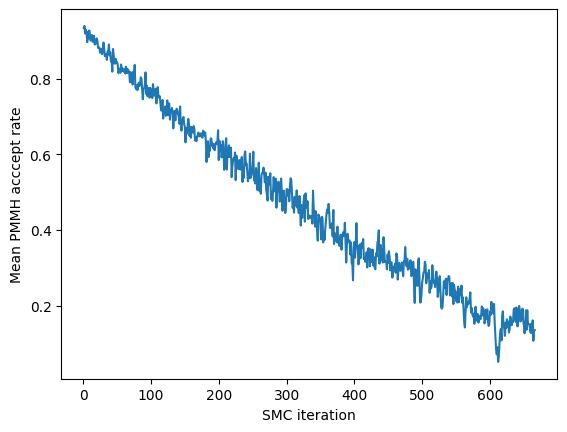

In [11]:
""" Visualize PMMH acceptance rates over iterations """

accept_rates = df['accept_rate']

plt.xlabel('SMC iteration')
plt.ylabel('Mean PMMH acccept rate')
plt.plot(accept_rates[1:])
plt.show()

In [16]:
""" Piece of code for estimating the variance of
a particle filter likelihood estimate at a given parameter value
"""

@njit
def likelihood_variance_estimate(temp, n_particles, ys, us, theta, n_repeats=100):
    """ Estimates the variance of the bootstrap particle filter
    likelihood estimate for given parameters.
    
    Parameters
    -
    Params for input to particle filter
    -
    temp        : float
                  tempering parameter
    n_particles : int
                  number of particles to use
    ys          : ndarray of shape (T,)
                  List of observations from the 
                  underlying state-space model
    us          : ndarray of shape (T,)
                  List of exogenous input parameters
                  in the underlying state-space model
    theta       : ndarray of shape (2,)
                  Parameters of the underlying state-space
                  model
    -
    Params for variance estimation
    -
    n_repeat    : int, default=100
                  Number of times to re-run the particle filter
                  for variance estimation
                  
    Returns
    -
    var         : float
                  Empirical variance of log-likelihood estimate
    log_liks    : ndarray of shape (n_repeats,)
                  List of log-likelihoods obtained from repeated particle filtering
    """
    log_liks = np.zeros(n_repeats)
    for r in range(n_repeats):
        _, _, log_lik = particle_filter(temp, n_particles, ys, us, theta)
        log_liks[r] = log_lik
    var = np.var(log_liks)
    return var, log_liks



@njit(parallel=True)
def estimate_variances_parallel(temp, n_particles, ys, us, thetas, n_repeats):
    n_samples = thetas.shape[0]
    vars = np.empty(n_samples, dtype=np.float64)
    for m in prange(n_samples):
        vars[m], _ = likelihood_variance_estimate(temp, n_particles, ys, us, thetas[m], n_repeats)
    return np.mean(vars), np.std(vars)


In [94]:
T = 200 # Number of observations
                              
# Exogenous input variables
rng = np.random.default_rng(seed=42) # Want to fix this while keeping the rest random
us = rng.normal(loc=0, scale=1, size=T)

# Sample observations from true state-space model
ys = sample_state_space_model(T=T,us=us,rng=rng)

n_particles = len(df["particles"].iloc[0]) # Number of particles

# Loop over temperatures and particles
iter_delay = 5
temps_evaluated = []
means_of_vars = []
stds_of_vars = []
particle_means = []
for temp, particles in zip(df["temp"][::iter_delay],df["particles"][::iter_delay]):
    print(f"Computing variances; temp={temp}")

    mean_var, std_var = estimate_variances_parallel(temp, n_particles, ys, us, particles, n_repeats=15)

    temps_evaluated.append(temp)
    means_of_vars.append(mean_var)
    stds_of_vars.append(std_var)
    particle_means.append(np.mean(particles,axis=0))

    print(f"Mean of variances: {mean_var}")

# Convert to numpy
temps_evaluated = np.array(temps_evaluated)
means_of_vars = np.array(means_of_vars)
stds_of_vars = np.array(stds_of_vars)
particle_means = np.array(particle_means)

Computing variances; temp=10.0
Mean of variances: 0.0187200751153997
Computing variances; temp=8.089205178129042
Mean of variances: 0.02644336167456512
Computing variances; temp=6.584221830276414
Mean of variances: 0.037031974625261886
Computing variances; temp=5.535461947870831
Mean of variances: 0.05164550720150848
Computing variances; temp=4.760250521213651
Mean of variances: 0.06885971312135611
Computing variances; temp=4.200541570153542
Mean of variances: 0.07623456828075588
Computing variances; temp=3.7013549942757846
Mean of variances: 0.10171703556523397
Computing variances; temp=3.2985890273620218
Mean of variances: 0.12006923374794837
Computing variances; temp=2.9981783054227207
Mean of variances: 0.14662185966944286
Computing variances; temp=2.7451987427107967
Mean of variances: 0.16012682550860727
Computing variances; temp=2.529275828645687
Mean of variances: 0.18055329271430598
Computing variances; temp=2.3321014859532694
Mean of variances: 0.1931553031852725
Computing var

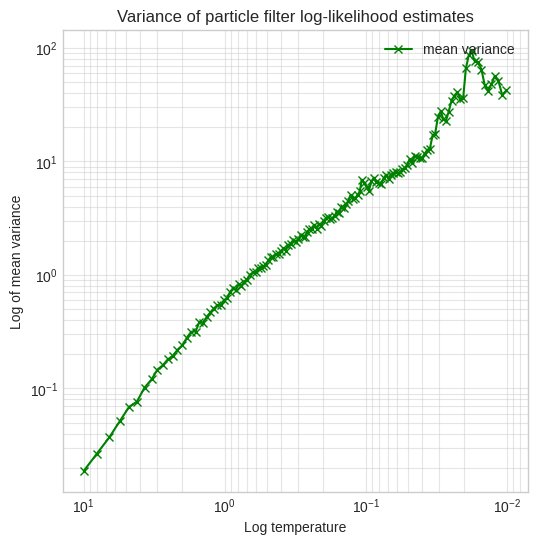

In [107]:
""" Plot mean of likelihood estimate variance
against temperature
"""

plt.figure(figsize=(6, 6)) 
plt.plot(temps_evaluated, means_of_vars, marker="x", color='g', label='mean variance')
plt.yscale('log')
plt.xscale('log')
plt.xlabel("Log temperature")
plt.gca().invert_xaxis() 
plt.ylabel("Log of mean variance")
plt.title("Variance of particle filter log-likelihood estimates")
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend(loc='upper right')
plt.show()

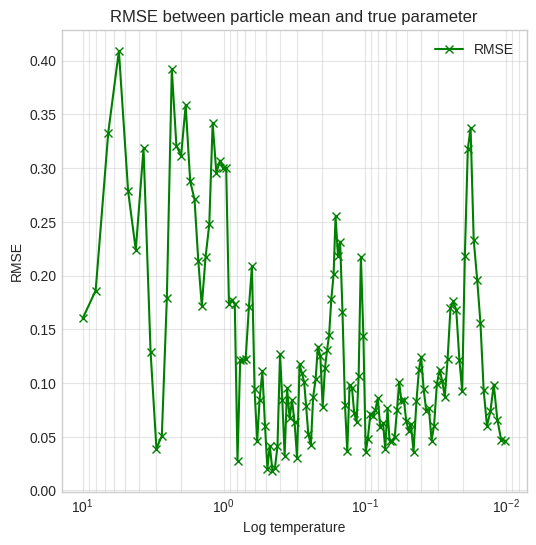

In [109]:
""" Plot RMSE between true parameters and particle means
against temperature
"""

particle_means = np.asarray(particle_means)

true_param = np.array([1,1])
rmses = np.sqrt(np.sum((particle_means - true_param)**2, axis=1))

plt.figure(figsize=(6, 6)) 
plt.plot(temps_evaluated, rmses, marker='x', color='g', label='RMSE')
plt.xlabel("Log temperature")
plt.xscale('log')
plt.gca().invert_xaxis() 
plt.ylabel("RMSE")
plt.title("RMSE between particle mean and true parameter")
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend(loc='upper right')
plt.show()